<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week4_%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#07 행렬 분해를 이용한 잠재 요인 협업 필터링 실습

SGD 기반의 행렬 분해를 구현하고 이를 기
반으로 사용자에게 영화를 추천해 보겠습니다.

In [1]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
    error = 0

    for i, j, r in non_zeros:
        pred = np.dot(P[i, :], Q[j, :].T)
        error += (r - pred) ** 2

    rmse = np.sqrt(error / len(non_zeros))

    return rmse

matrix_factorization(R, K, steps=200,
learning_rate=0.01, r lambda = 0.01)에서 R은 원본 사용지一아이템 평점 행렬이며, K는 잠재 요인
의 차원 수, steps는 SGD 의 반복 횟수, learningjrate는 학습률, rjambda는 L2 규제 계수

In [9]:
def matrix_factorization(R,K,steps=200,learning_rate=0.01,r_lambda=0.01):
  num_users,num_items=R.shape
  np.random.seed(1)
  P=np.random.normal(scale=1./K,size=(num_users,K))
  Q=np.random.normal(scale=1./K,size=(num_items,K))
  non_zeros=[(i,j,R[i,j])for i in range(num_users) for j in range(num_items) if R[i,j]>0]
  for step in range(steps):
    for i,j,r in non_zeros:
      eij=r-np.dot(P[i,:],Q[j,:].T)
      P[i,:]=P[i,:]+learning_rate*(eij*Q[j,:]-r_lambda*P[i,:])
      Q[j,:]=Q[j,:]+learning_rate*(eij*P[i,:]-r_lambda*Q[j,:])
    rmse=get_rmse(R,P,Q,non_zeros)
    if(step%10)==0:
      print("###iteration step:",step,"rmse:",rmse)
  return P,Q


In [10]:
import pandas as pd
import numpy as np

movies=pd.read_csv('/content/movies.csv')
ratings=pd.read_csv('/content/ratings.csv')

ratings=ratings[['userId','movieId','rating']]
ratings_matrix=ratings.pivot_table('rating',index='userId',columns='movieId')
rating_movies=pd.merge(ratings,movies,on='movieId')
ratings_matrix=rating_movies.pivot_table('rating',index='userId',columns='title')

In [11]:
P,Q=matrix_factorization(ratings_matrix.values,K=50,steps=200,learning_rate=0.01,
                         r_lambda=0.01)
pred_matrix=np.dot(P,Q.T)

###iteration step: 0 rmse: 2.9023619751337115
###iteration step: 10 rmse: 0.7335768591017939
###iteration step: 20 rmse: 0.5115539026853438
###iteration step: 30 rmse: 0.37261628282537734
###iteration step: 40 rmse: 0.29608182991810145
###iteration step: 50 rmse: 0.2520353192341621
###iteration step: 60 rmse: 0.22487503275269882
###iteration step: 70 rmse: 0.20685455302331512
###iteration step: 80 rmse: 0.19413418783028674
###iteration step: 90 rmse: 0.1847008200272031
###iteration step: 100 rmse: 0.17742927527209082
###iteration step: 110 rmse: 0.17165226964707506
###iteration step: 120 rmse: 0.16695181946871496
###iteration step: 130 rmse: 0.16305292191997453
###iteration step: 140 rmse: 0.159766919296796
###iteration step: 150 rmse: 0.15695986999457337
###iteration step: 160 rmse: 0.15453398186715442
###iteration step: 170 rmse: 0.1524161855107769
###iteration step: 180 rmse: 0.1505508073962834
###iteration step: 190 rmse: 0.14889470913232075


In [12]:
ratings_pred_matrix=pd.DataFrame(data=pred_matrix,index=ratings_matrix.index,
                                columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


In [13]:
# 사용자 9번 영화 추천

def get_unseen_movies(ratings_matrix, userId):

    # userId로 입력받은 사용자의 모든 영화 정보를 추출
    # 영화명(title)을 index로 가지는 Series 반환
    user_rating = ratings_matrix.loc[userId, :]

    # 평점이 0보다 크면 이미 본 영화
    already_seen = user_rating[user_rating > 0].index.tolist()

    # 전체 영화 목록
    movies_list = ratings_matrix.columns.tolist()

    # 이미 본 영화 제외
    unseen_list = [movie for movie in movies_list if movie not in already_seen]

    return unseen_list


def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):

    # 예측 평점 중 안 본 영화만 선택
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]

    return recomm_movies

In [14]:
unseen_list=get_unseen_movies(ratings_matrix,9)
recomm_movies=recomm_movie_by_userid(ratings_pred_matrix,9,unseen_list,top_n=10)
recomm_movies=pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,
                           columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


# 08 파이썬 추천 시스템 패키지 一 Surprise

In [2]:
! pip install scikit-surprise

  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


## Surprise 를 이용한 추천 시스템 구축

In [3]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

In [4]:
data=Dataset.load_builtin('ml-100k')
trainset,testset=train_test_split(data,test_size=.25,random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


한 번 내려받아 로컬 디렉터리에 데이터가 저장된 후에는 Dataset.load_builtin('ml-lOOk')< 호출
하면 무비렌즈 사이트에 접속하지 않고 저장된 데이터 세트를 로딩

 Surprise가 내려받은 ml-100k, ml-1m은 과거 버전의 데이
터 세트입니다. 최신 데이터 세트인 ratings.csv의 경우 칼럼 분리 문자가 콤마(,)인 CSV 파일이지만,
과거 버전의 데이터 파일은 분리 문자가 탭(\t) 문자

Surprise는 자체적으로 로우 레벨의 데이터를 칼럼 레벨
의 데이터로 변경하므로 원본인 로우 레벨의 사용자-아이템 평점 데이터를 데이터 세트로 적용해야 합
니다

In [5]:
algo=SVD(random_state=0)
algo.fit(trainset)

학습된 추천 알고리즘을 기반으로 테스트 데이터 세트에 대해 추천을 수행하겠습니다. Surprise에서
추천을 예측하는 메서드는 test()와 predict(), 두 개

 test()는 사용자-아이템 평점 데이터 세
트 전체에 대해서 추천을 예측하는 메서드입니다. 즉, 입력된 데이터 세트에 대해 추천 데이터 세트를
만들어 줍니다. predict()는 개별 사용자와 영화에 대한 추천 평점을 반환해 줍니다.

In [6]:
predictions=algo.test(testset)
print('prediction type: ',type(predictions),'size:',len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type:  <class 'list'> size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

 Prediction 객체는 Surprise 패키지에서 제공하는 데이
터 타입이며, 개별 사용자 아이디(uid), 영화(또는 아이템) 아이디(iid)와 실제 평점(r_ui) 정보에 기반
해 Surprise의 추천 예측 평점(est) 데이터를 튜플 형태

‘was_impossible’이 True이면 예측값을 생성할 수 없는 데이터라는 의미

리스트 객체 내에 내포된 Prediction 객체의 uid, iid, r_ui, est 등의 속성에 접근하려면 객체명.uid와
같은 형식으로 가능

In [7]:
[(pred.uid,pred.iid,pred.est) for pred in predictions[:3]]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

In [8]:
uid=str(196)
iid=str(302)
pred=algo.predict(uid,iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


test() 메서드는 입력 데이터 세트의 모든 사용자와 아이템 아이디에 대해서 predict()를 반복적으로
수행한 결과라고 생각하면 좀 더 이해하기 쉬울 것

테스트 데이터 세트를 이용해 추천 예측 평점과 실제 평점과의 차이를 평가

In [9]:
# Surprise의 accuracy 모듈
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

## Surprise 주요 모듈 소개
* Dataset  
데이터의 첫 번째 칼럼을 사용자 아이디, 두
번째 칼럼을 아이템 아이디, 세 번째 칼럼을 평점으로 가정해 데이터를 로딩하고 네 번째 칼럼부터는
아예 로딩을 수행하지 않습니다.

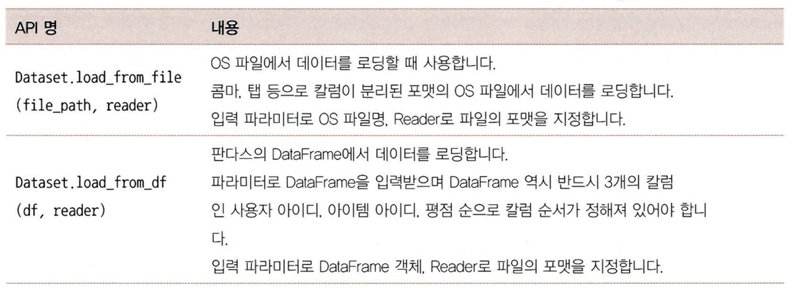

OS 파일 데이터를 Surprise 데이터 세트로 로딩

먼저 Surprise에 OS 파일을 로딩할 때의 주의할 점은 로딩
되는 데이터 파일에 칼럼명을 가지는 헤더 문자열이 있어서
는 안 된다는 것입니다.

In [13]:
import pandas as pd
ratings=pd.read_csv('ratings.csv')
ratings.to_csv('ratings_noh.csv',index=False, header=False)

Dataset.load_from_file()을 적용하기 전에 Reader 클래스를 이용해 데이터 파일의 파싱 포맷을 정
의해야 합니다.

 4개의 칼럼이 사용자 아이디, 아이템 아이디, 평점, 타임스탬프임을 로딩할 때 알려줘야 합니다.

In [15]:
from surprise import Reader

reader=Reader(line_format='user item rating timestamp',sep=',',rating_scale=(0.5,5))
data=Dataset.load_from_file('ratings_noh.csv',reader=reader)

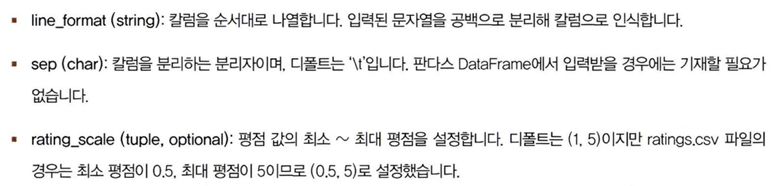

In [16]:
trainset,testset=train_test_split(data,test_size=.25,random_state=0)
algo=SVD(n_factors=50,random_state=0)
algo.fit(trainset)
predictions=algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

### 판다스 DataFrame에서 Surprise 데이터 세트로 로딩

주의할 점은 DataFrame 역시 사용자 아이디, 아이템 아이디, 평점 칼럼 순서를 지켜야
한다는 것

In [17]:
from numpy.matrixlib import test
import pandas as pd
from surprise import Reader,Dataset

ratings=pd.read_csv('ratings.csv')
reader=Reader(rating_scale=(0.5,5))
data=Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)
trainset,testset=train_test_split(data,test_size=.25,random_state=0)
algo=SVD(n_factors=50,random_state=0)
algo.fit(trainset)
predictions=algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

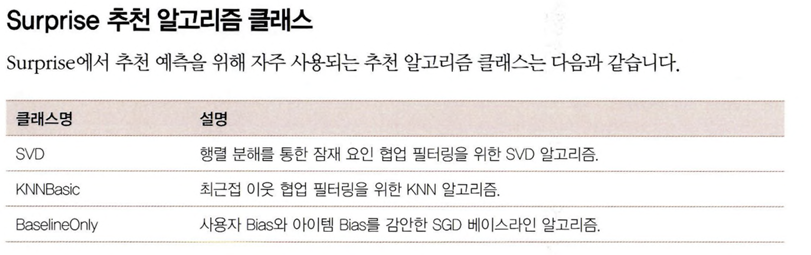

Surprise SVD의 비용 함수는 사용자 베이스라인(Baseline) 편향성을 감안한 평점 예측에 Regular-
ization을 적용한 것

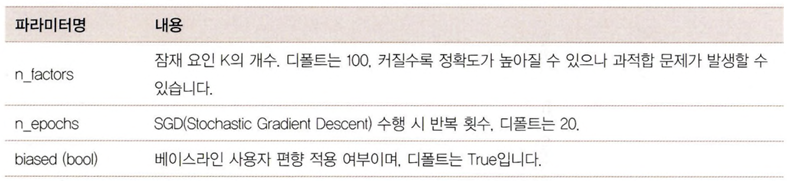

SVD十+ 알고리즘의 RMSE, MAE 성적이 가장 좋지만, 상대적으로 시간이 너무 오래 걸려 데이터가
조금만 더 커져도 사용하기가 어려울 것으로 보입니다. SVD十+를 제외하면 SVD와 k-NN Baseline
이 가장 성능 평가 수치가 좋습니다. k-NN 자체는 성능이 상대적으로 뒤지지만, Baseline을 결합한
경우 성능 평가 수치가 대폭 향상됐습니다. Baseline이라는 의미는 각 개인이 평점을 부여하는 성향을
반영해 평점을 계산하는 방식을 말합니다.

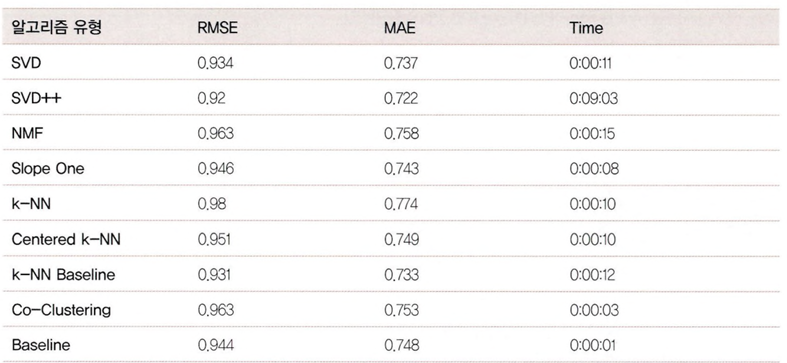

## 베이스라인 평점

싫은 소리를 별로 안 하는 사람의 경우는 전반적으로 평가에 후한 경향이 있습니
다. 반면에 다른 이를 생각해서라도 냉정한 평가를 해야 한다고 생각하는 사람도 있을 것입니다. 이러
한 개인의 성향을 반영해 아이템 평가에 편향성(bias) 요소를 반영하여 평점을 부과하는 것을 베이스라
인 평점 (Baseline Rating) 이라고 힙니다

보통 베이스라인 평점은 전체 평균 평점 十 사용자 편향 점수 + 아이템 편향 점수 공식으로 계산됩
니다.

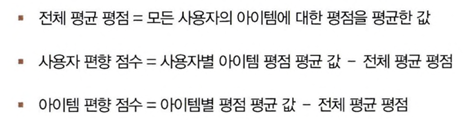

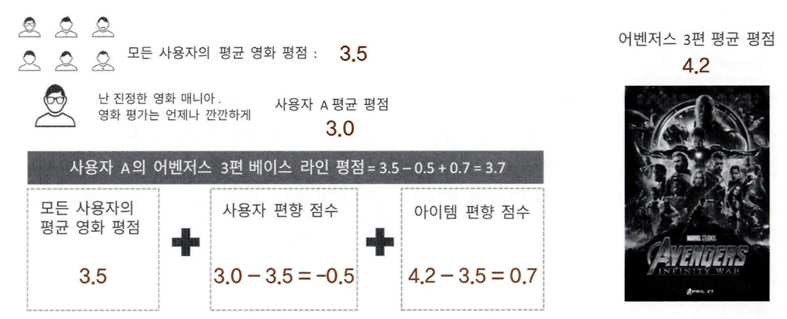

## 교차 검증과 하이퍼 파라미터 튜닝

Surprise는 교차 검증과 하이퍼 파라미터 튜닝을 위해 사이킷런과 유사한 cross_validate( )와
GridSearchCV 클래스를 제공

cross_validate()의 인자로 알고리즘 객체, 데이터, 성능 평가 방법(measures), 폴드 데이터 세트 개
수(cv)를 입력

In [18]:
from surprise.model_selection import cross_validate

ratings=pd.read_csv('ratings.csv')
reader=Reader(rating_scale=(0.5,5))
data=Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)

algo=SVD(random_state=0)
cross_validate(algo,data,measures=['RMSE','MAE'],cv=5,verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8682  0.8844  0.8761  0.8730  0.8725  0.8748  0.0054  
MAE (testset)     0.6674  0.6781  0.6740  0.6682  0.6709  0.6717  0.0040  
Fit time          2.52    1.46    1.50    1.47    1.66    1.72    0.41    
Test time         0.11    0.28    0.11    0.28    0.21    0.20    0.08    


{'test_rmse': array([0.86817531, 0.88437291, 0.87614499, 0.87296436, 0.8724944 ]),
 'test_mae': array([0.66740179, 0.67813257, 0.67399424, 0.66817768, 0.67093595]),
 'fit_time': (2.520409107208252,
  1.4564189910888672,
  1.501568078994751,
  1.472196102142334,
  1.6621217727661133),
 'test_time': (0.1128394603729248,
  0.2835254669189453,
  0.10643625259399414,
  0.27592968940734863,
  0.2089216709136963)}

In [20]:
from surprise.model_selection import GridSearchCV

param_grid={'n_epochs':[20,40,60],'n_factors':[50,100,200]}
gs=GridSearchCV(SVD,param_grid,measures=['rmse','mae'],cv=3)
gs.fit(data)

print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8755397797659342
{'n_epochs': 20, 'n_factors': 50}


## Surprise를 이용한 개인화 영화 추천 시스템 구축

지금까지 살펴본 Surprise 예제는 학습 데
이터로 fit()을 호출해 학습한 뒤 테스트 데이터로 test()를 호출해 예측 평점을 계산하고 MSE/RMSE
로 성능을 평가했습니다. 이제는 Surprise 패키지로 학습된 추천 알고리즘을 기반으로 특정 사용자가
아직 평점을 매기지 않은(관람하지 않은) 영화 중에서 개인 취향에 가장 적절한 영화를 추천해 보겠습
니다

학습 데이터와 테스트 데이터로 분리하지 않고 전체를 학습 데
이터로 사용

그런데 Surprise는 데이터 세트를 train_test_split()을 이용해 내부에서 사용하는
TrainSet 클래스 객체로 변환하지 않으면 fit()을 통해 학습할 수가 없습니다. 따라서 데이터 세트를 그
대로 fit()에 적용한 다음 코드는 오류를 일으킵니다

In [21]:
data=Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)
algo=SVD(n_factors=50,random_state=0)
algo.fit(data)

AttributeError: 'DatasetAutoFolds' object has no attribute 'n_users'

DatasetAutoFolds 객체를 생성한 뒤에 build_full_trainset() 메서드를 호출하면 전체 데이터를 학습
데이터 세트로 만들 수 있습니다

In [23]:
from surprise.dataset import DatasetAutoFolds

reader=Reader(line_format='user item rating timestamp',sep=',',rating_scale=(0.5,5))
data_folds=DatasetAutoFolds(ratings_file='ratings_noh.csv',reader=reader)
trainset=data_folds.build_full_trainset()

In [24]:
algo=SVD(n_epochs=20,n_factors=50,random_state=0)
algo.fit(trainset)

특정 사용자는 userid = 9인 사용자로 지정하겠습니다. 간단하게 Surprise 패키지의 API를 이용해 예
제를 수행하기 위해 userid 9가 아직 평점을 매기지 않은 영화를 movield 42로 선정한 뒤 예측 평점
을 계산해 보겠습니다.

영화의 상세 정보는 movies.csv 파일에 있으므로 해당 파일을 DataFrame으
로로딩합니다

In [25]:
movies=pd.read_csv('movies.csv')
movieIds=ratings[ratings['userId']==9]['movieId']
if movieIds[movieIds==42].count()==0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')
print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


In [26]:
uid=str(9)
iid=str(42)
pred=algo.predict(uid,iid,verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


이제 사용자가 평점을 매기지 않은 전체 영화를 추출한 뒤에 예측 평점
순으로 영화를 추천해 보겠습니다. 먼저 추천 대상이 되는 영화를 추출하겠습니다.

In [28]:
def get_unseen_surprise(ratings,movies,userId):
  seen_movies=ratings[ratings['userId']==userId]['movieId'].tolist()
  total_movies=movies['movieId'].tolist()
  unseen_movies=[movie for movie in total_movies if movie not in seen_movies]
  print('평점 매긴 영화 수:',len(seen_movies),'추천 대상 영화 수 :',len(unseen_movies),
        '전체 영화 수:',len(total_movies))
  return unseen_movies
unseen_movies=get_unseen_surprise(ratings,movies,9)


평점 매긴 영화 수: 46 추천 대상 영화 수 : 9696 전체 영화 수: 9742


이 중 앞에서 학습된 추천 알고리즘 클래스인 SVD를 이용해 높은 예측 평점을 가진 순으
로 영화를 추천해 보겠습니다. 이를 위해 recomm_movie_by_surprise() 함수를 새롭게 생성합니다.
이 함수는 인자로 학습이 완료된 추천 알고리즘 객체, 추천 대상 사용자 아이디, 추천 대상 영화의 리스
트 객체, 그리고 추천 상위 N개 개수를 받습니다.

In [31]:
def recomm_movie_by_surprise(algo,userId,unseen_movies,top_n=10):
  predictions=[algo.predict(str(userId),str(movieId)) for movieId in unseen_movies]
  def sortkey_est(pred):
    return pred.est

  predictions.sort(key=sortkey_est,reverse=True)
  top_predictions=predictions[:top_n]
  top_movie_ids=[int(pred.iid) for pred in top_predictions]
  top_movie_rating=[pred.est for pred in top_predictions]
  top_movie_titles=movies[movies.movieId.isin(top_movie_ids)]['title']
  top_movie_preds=[(id,title,rating) for id, title, rating in zip(top_movie_ids,top_movie_titles,top_movie_rating)]
  return top_movie_preds

unseen_movies=get_unseen_surprise(ratings,movies,9)
top_movie_preds=recomm_movie_by_surprise(algo,9,unseen_movies,top_n=10)
print('#### Top-10 추천 영화 리스트 ####')
for top_movie in top_movie_preds:
  print(top_movie[1],":",top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수 : 9696 전체 영화 수: 9742
#### Top-10 추천 영화 리스트 ####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122657
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957


 Surprise 패키지는 복잡한 알고리즘을 직접 구현하지 않고도 쉽고 간결
한 API를 이용해 파이썬 기반게서 추천 시스템을 구축할 수 있도록 해줍니다